# 03 Funnel Analysis

This notebook analyzes the ecommerce funnel using the cleaned dataset and focuses only on funnel metrics and simple visualizations.

## 1. Import libraries and define file paths

We import the libraries we need and set the input and output paths for the funnel analysis files.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_PATH = Path("..") / "outputs" / "events_cleaned.csv"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OVERALL_OUTPUT = OUTPUT_DIR / "funnel_overall.csv"
MONTHLY_OUTPUT = OUTPUT_DIR / "funnel_monthly.csv"
CATEGORY_OUTPUT = OUTPUT_DIR / "funnel_category.csv"
BRAND_OUTPUT = OUTPUT_DIR / "funnel_brand.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Input file: {INPUT_PATH.resolve()}")

Input file: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\events_cleaned.csv


## 2. Load the cleaned dataset

We read the cleaned dataset from the `outputs` folder.

In [2]:
df = pd.read_csv(INPUT_PATH, parse_dates=["event_time"])
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Briefly inspect the cleaned dataset

This is a quick check to confirm the structure before calculating funnel metrics.

In [3]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Event types:", sorted(df["event_type"].dropna().unique().tolist()))
df.head()

Shape: (884474, 12)
Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'event_date', 'event_month', 'event_week']
Event types: ['cart', 'purchase', 'view']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_month,event_week
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,Unknown,31.90,1515915625519388267,LJuJVLEjPT,2020-09-24,2020-09,2020-09-21/2020-09-27
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020-09-24,2020-09,2020-09-21/2020-09-27
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,Unknown,Unknown,9.81,1515915625513238515,4TMArHtXQy,2020-09-24,2020-09,2020-09-21/2020-09-27
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020-09-24,2020-09,2020-09-21/2020-09-27
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,Unknown,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,2020-09-24,2020-09,2020-09-21/2020-09-27


## 4. Keep only the main funnel stages

For this project, the funnel stages are `view`, `cart`, and `purchase`.

In [4]:
funnel_stages = ["view", "cart", "purchase"]
funnel_df = df[df["event_type"].isin(funnel_stages)].copy()
print("Shape after filtering to funnel stages:", funnel_df.shape)

Shape after filtering to funnel stages: (884474, 12)


## 5. Define a helper function for funnel metrics

This function calculates counts and conversion rates for any grouping level.

In [5]:
def calculate_funnel_metrics(dataframe, group_col=None):
    if group_col is None:
        counts = dataframe["event_type"].value_counts()
        result = pd.DataFrame({
            "views": [counts.get("view", 0)],
            "carts": [counts.get("cart", 0)],
            "purchases": [counts.get("purchase", 0)],
        })
    else:
        counts = (
            dataframe.groupby([group_col, "event_type"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=funnel_stages, fill_value=0)
            .reset_index()
        )
        result = counts.rename(columns={
            "view": "views",
            "cart": "carts",
            "purchase": "purchases",
        })

    result["view_to_cart_rate"] = (result["carts"] / result["views"]).where(result["views"] > 0, 0)
    result["cart_to_purchase_rate"] = (result["purchases"] / result["carts"]).where(result["carts"] > 0, 0)
    result["view_to_purchase_rate"] = (result["purchases"] / result["views"]).where(result["views"] > 0, 0)

    return result

## 6. Calculate overall funnel metrics

This gives us the main funnel counts and conversion rates for the full dataset.

In [6]:
funnel_overall = calculate_funnel_metrics(funnel_df)
funnel_overall

,views,carts,purchases,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,793099,54032,37343,0.068128,0.691127,0.047085


## 7. Calculate monthly funnel metrics

This shows how the funnel changes over time by `event_month`.

In [7]:
funnel_monthly = calculate_funnel_metrics(funnel_df, group_col="event_month").sort_values("event_month")
funnel_monthly.head()

event_type,event_month,views,carts,purchases,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,2020-09,25640,1412,1007,0.055070,0.713173,0.039275
1,2020-10,146414,8728,6276,0.059612,0.719065,0.042865
2,2020-11,170082,10435,7574,0.061353,0.725827,0.044531
3,2020-12,136719,9342,6529,0.068330,0.698887,0.047755
4,2021-01,166431,12695,8315,0.076278,0.654982,0.049961


## 8. Calculate category funnel metrics

This summarizes funnel performance by product category.

In [8]:
funnel_category = calculate_funnel_metrics(funnel_df, group_col="category_code")
funnel_category = funnel_category.sort_values(["view_to_purchase_rate", "purchases"], ascending=[False, False])
funnel_category.head(10)

event_type,category_code,views,carts,purchases,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
53,computers.peripherals.camera,4363,589,521,0.134999,0.884550,0.119413
60,computers.peripherals.scanner,1599,200,165,0.125078,0.825000,0.103189
107,stationery.stapler,741,48,66,0.064777,1.375000,0.089069
105,stationery.cartrige,32919,3041,2739,0.092378,0.900691,0.083204
49,computers.ebooks,2825,268,212,0.094867,0.791045,0.075044
47,computers.components.videocards,97039,12684,6888,0.130710,0.543046,0.070982
90,electronics.video.projector,1374,118,94,0.085881,0.796610,0.068413
59,computers.peripherals.printer,37453,3183,2557,0.084987,0.803330,0.068272
92,electronics.video.tv_remote,932,68,62,0.072961,0.911765,0.066524
83,electronics.calculator,152,8,10,0.052632,1.250000,0.065789


## 9. Calculate brand funnel metrics

This summarizes funnel performance by brand.

In [9]:
funnel_brand = calculate_funnel_metrics(funnel_df, group_col="brand")
funnel_brand = funnel_brand.sort_values(["view_to_purchase_rate", "purchases"], ascending=[False, False])
funnel_brand.head(10)

event_type,brand,views,carts,purchases,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
630,noreve,2,0,7,0.000000,0.000000,3.500000
700,polaroid,3,1,3,0.333333,3.000000,1.000000
2,accesstyle,2,1,2,0.500000,2.000000,1.000000
976,yeastar,14,2,9,0.142857,4.500000,0.642857
539,marvo,3,1,1,0.333333,1.000000,0.333333
712,printpro,51,8,13,0.156863,1.625000,0.254902
579,mobparts,13,6,3,0.461538,0.500000,0.230769
66,atrix,5,1,1,0.200000,1.000000,0.200000
470,klevv,5,1,1,0.200000,1.000000,0.200000
166,codyson,365,63,71,0.172603,1.126984,0.194521


## 10. Save funnel summary tables

These CSV files can be reused later for dashboards and reporting.

In [10]:
funnel_overall.to_csv(OVERALL_OUTPUT, index=False)
funnel_monthly.to_csv(MONTHLY_OUTPUT, index=False)
funnel_category.to_csv(CATEGORY_OUTPUT, index=False)
funnel_brand.to_csv(BRAND_OUTPUT, index=False)

print(f"Saved: {OVERALL_OUTPUT.resolve()}")
print(f"Saved: {MONTHLY_OUTPUT.resolve()}")
print(f"Saved: {CATEGORY_OUTPUT.resolve()}")
print(f"Saved: {BRAND_OUTPUT.resolve()}")

Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\funnel_overall.csv
Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\funnel_monthly.csv
Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\funnel_category.csv
Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\funnel_brand.csv


## 11. Visualize the overall funnel counts

This bar chart shows the total number of events at each funnel stage.

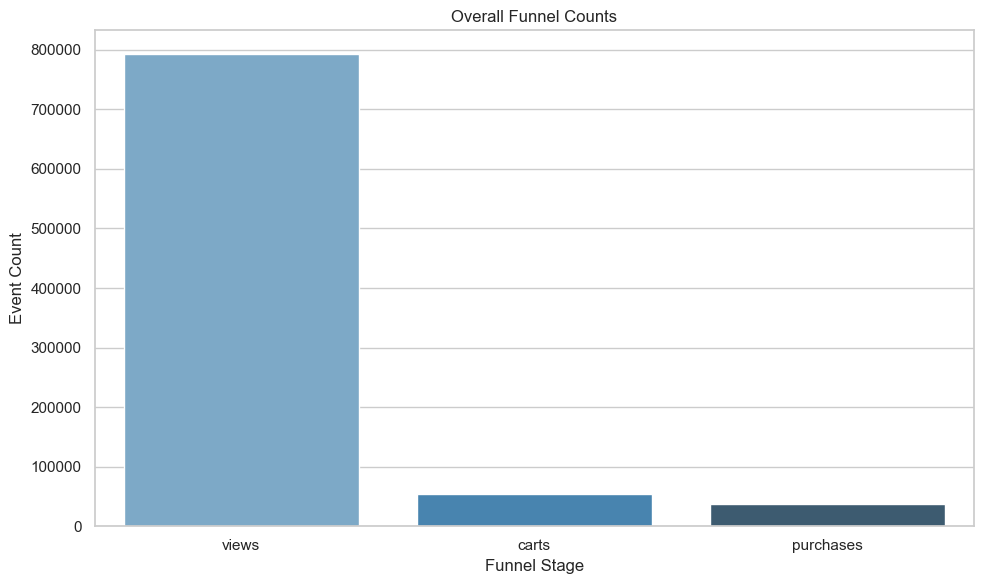

In [11]:
overall_plot = funnel_overall[["views", "carts", "purchases"]].T.reset_index()
overall_plot.columns = ["stage", "count"]

sns.barplot(data=overall_plot, x="stage", y="count", hue="stage", palette="Blues_d", legend=False)
plt.title("Overall Funnel Counts")
plt.xlabel("Funnel Stage")
plt.ylabel("Event Count")
plt.tight_layout()
plt.show()

## 12. Visualize the monthly funnel trend

This line chart shows how views, carts, and purchases change by month.

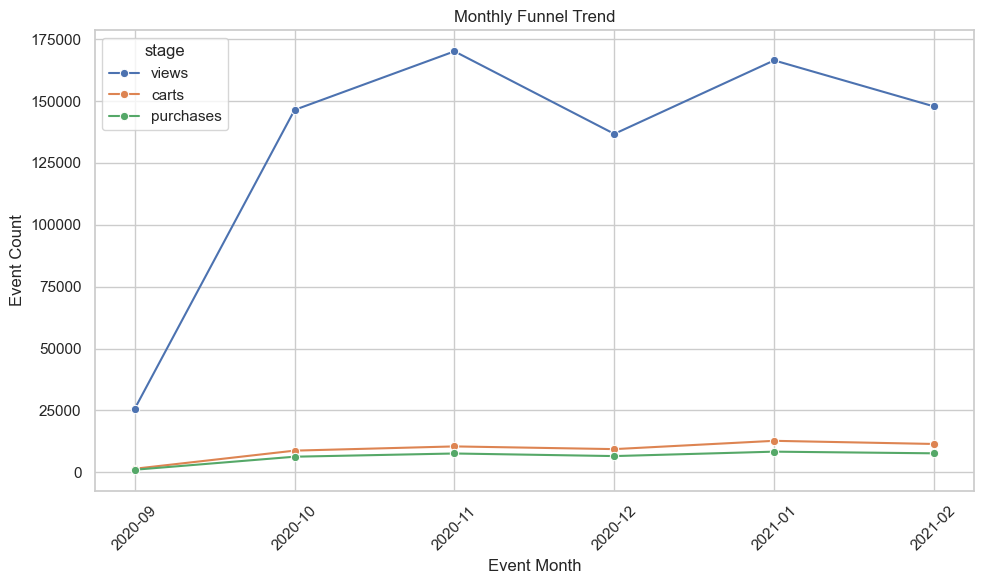

In [12]:
monthly_plot = funnel_monthly[["event_month", "views", "carts", "purchases"]].melt(
    id_vars="event_month",
    value_vars=["views", "carts", "purchases"],
    var_name="stage",
    value_name="count",
)

sns.lineplot(data=monthly_plot, x="event_month", y="count", hue="stage", marker="o")
plt.title("Monthly Funnel Trend")
plt.xlabel("Event Month")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Visualize the top categories by purchase conversion

To keep the chart meaningful, we only look at categories with at least 100 views.

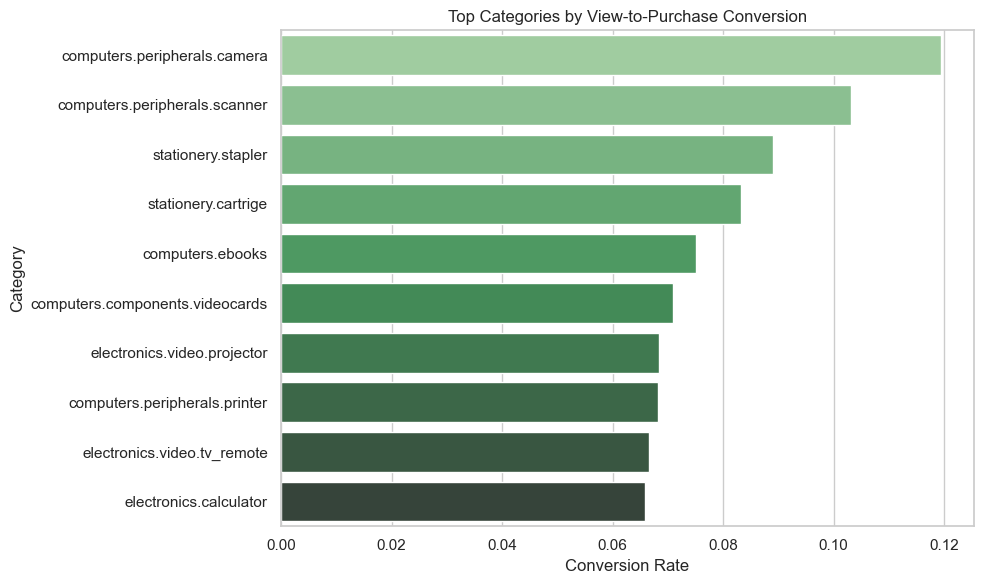

In [13]:
top_category_plot = (
    funnel_category[funnel_category["views"] >= 100]
    .nlargest(10, "view_to_purchase_rate")
    .copy()
)

sns.barplot(
    data=top_category_plot,
    x="view_to_purchase_rate",
    y="category_code",
    hue="category_code",
    palette="Greens_d",
    legend=False,
)
plt.title("Top Categories by View-to-Purchase Conversion")
plt.xlabel("Conversion Rate")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 14. Visualize the top brands by purchase conversion

To keep the chart meaningful, we only look at brands with at least 100 views.

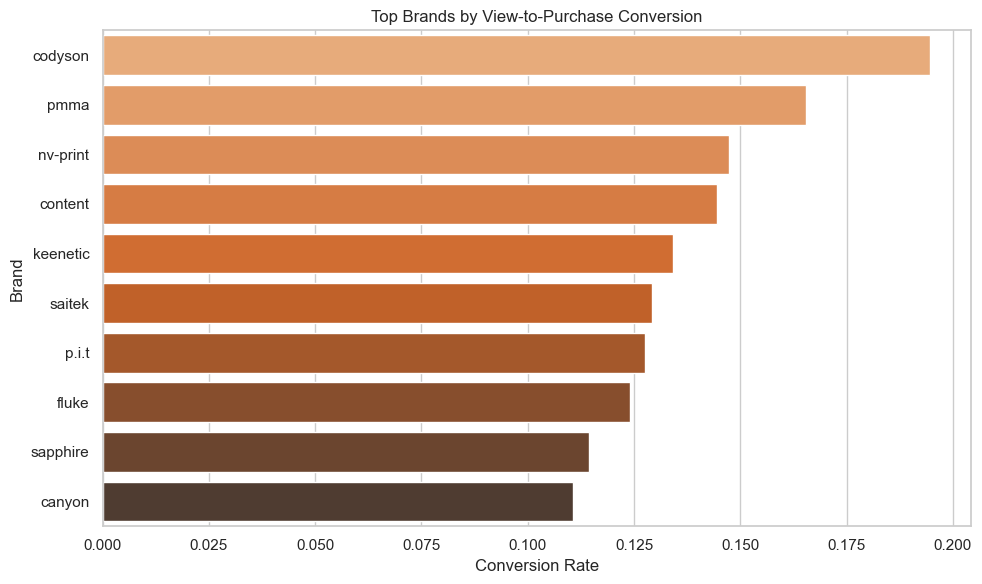

In [14]:
top_brand_plot = (
    funnel_brand[funnel_brand["views"] >= 100]
    .nlargest(10, "view_to_purchase_rate")
    .copy()
)

sns.barplot(
    data=top_brand_plot,
    x="view_to_purchase_rate",
    y="brand",
    hue="brand",
    palette="Oranges_d",
    legend=False,
)
plt.title("Top Brands by View-to-Purchase Conversion")
plt.xlabel("Conversion Rate")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

## 15. Print a short summary of the funnel findings

This final section gives a simple text summary of the main results from the funnel analysis.

In [15]:
overall_row = funnel_overall.iloc[0]
best_month = funnel_monthly.sort_values("view_to_purchase_rate", ascending=False).iloc[0]
best_category = funnel_category[funnel_category["views"] >= 100].sort_values("view_to_purchase_rate", ascending=False).iloc[0]
best_brand = funnel_brand[funnel_brand["views"] >= 100].sort_values("view_to_purchase_rate", ascending=False).iloc[0]

print("Key Funnel Findings")
print("- Total views:", int(overall_row["views"]))
print("- Total carts:", int(overall_row["carts"]))
print("- Total purchases:", int(overall_row["purchases"]))
print(f"- View-to-cart conversion rate: {overall_row['view_to_cart_rate']:.2%}")
print(f"- Cart-to-purchase conversion rate: {overall_row['cart_to_purchase_rate']:.2%}")
print(f"- View-to-purchase conversion rate: {overall_row['view_to_purchase_rate']:.2%}")
print(f"- Best month by view-to-purchase conversion: {best_month['event_month']} ({best_month['view_to_purchase_rate']:.2%})")
print(f"- Top category by view-to-purchase conversion with at least 100 views: {best_category['category_code']} ({best_category['view_to_purchase_rate']:.2%})")
print(f"- Top brand by view-to-purchase conversion with at least 100 views: {best_brand['brand']} ({best_brand['view_to_purchase_rate']:.2%})")

Key Funnel Findings
- Total views: 793099
- Total carts: 54032
- Total purchases: 37343
- View-to-cart conversion rate: 6.81%
- Cart-to-purchase conversion rate: 69.11%
- View-to-purchase conversion rate: 4.71%
- Best month by view-to-purchase conversion: 2021-02 (5.17%)
- Top category by view-to-purchase conversion with at least 100 views: computers.peripherals.camera (11.94%)
- Top brand by view-to-purchase conversion with at least 100 views: codyson (19.45%)
